# Exploratory Data Analysis (EDA)
## Dataset: POS_CASH_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `POS_CASH_balance` dataset from the Home Credit risk modeling case. This table contains monthly balance snapshots of previous POS and cash loans held by applicants at Home Credit, providing behavioral signals on installment payment history for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `POS_CASH_balance` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (POS_CASH_balance to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of POS and cash loan balance behavior

---

## 🧠 Key Questions
- What is the monthly payment behavior profile of applicants on previous POS and cash loans?
- How do installment completion and overdue patterns relate to default behavior?
- What aggregated signals from POS_CASH_balance are most predictive of default?
- Are there patterns in contract status that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated POS_CASH_balance features ready for merging into the main modeling table
- Business insights on installment payment behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset POS_CASH_balance
pos_cash_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\POS_CASH_balance.csv'
df_pos = pd.read_csv(pos_cash_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **10,001,358 observations** and **8 features**, representing monthly balance snapshots of previous POS and cash loans held by applicants at Home Credit. Each row corresponds to one month of history for a given previous loan, linked to an applicant via `SK_ID_CURR` and to a specific previous loan via `SK_ID_PREV`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (link to previous_application) and `SK_ID_CURR` (link to main table)
- **Numerical features**: `MONTHS_BALANCE` (relative month), `CNT_INSTALMENT` (total installments), `CNT_INSTALMENT_FUTURE` (remaining installments), `SK_DPD` (days past due), `SK_DPD_DEF` (days past due defined)
- **Categorical feature**: `NAME_CONTRACT_STATUS`, indicating the contract status for that month

In [4]:
df_pos.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   str    
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 610.4 MB


# 2. Contract Status Distribution

The contract status distribution shows the monthly status of previous POS and cash loans held by applicants at Home Credit. Understanding the proportion of active, completed, and delinquent contracts provides an initial signal of the payment behavior profile across applicants.

- Total Active: 9,151,119 (~91.50%)
- Total Completed: 744,883 (~7.45%)
- Total Signed: 87,260 (~0.87%)
- Total Demand: 7,065 (~0.07%)
- Total Returned to the store: 5,461 (~0.05%)
- Total Approved: 4,917 (~0.05%)
- Total Amortized debt: 636 (~0.01%)
- Total Canceled: 15 (~0.00%)
- Total XNA: 2 (~0.00%)

The vast majority of monthly records are **Active (~91.50%)**, reflecting that most observations represent ongoing loan months. **Completed (~7.45%)** represents fully settled loans. `Demand`, `Returned to the store`, and `Amortized debt` are rare but may carry risk signal worth preserving during aggregation. `Canceled` and `XNA` are negligible with only 17 combined records.

In [5]:
# Contract status value counts
print(df_pos['NAME_CONTRACT_STATUS'].value_counts())
print(f"\nContract Status Distribution (%):")
print((df_pos['NAME_CONTRACT_STATUS'].value_counts() / len(df_pos) * 100).round(2))

NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

Contract Status Distribution (%):
NAME_CONTRACT_STATUS
Active                   91.50
Completed                 7.45
Signed                    0.87
Demand                    0.07
Returned to the store     0.05
Approved                  0.05
Amortized debt            0.01
Canceled                  0.00
XNA                       0.00
Name: count, dtype: float64


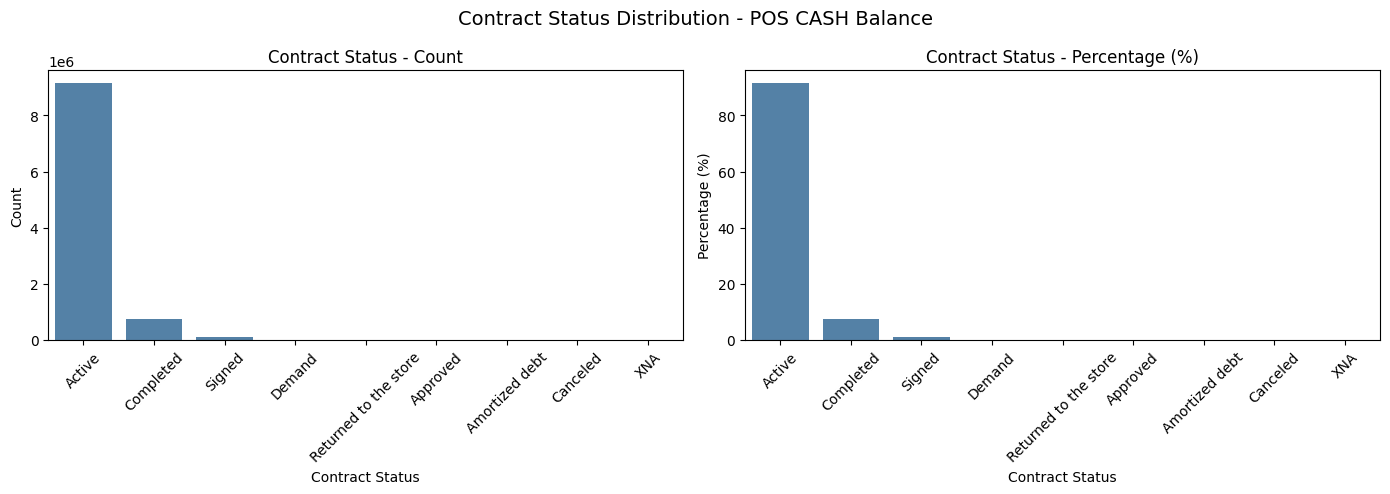

In [6]:
# Bar plot - contract status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_status_counts = df_pos['NAME_CONTRACT_STATUS'].value_counts()
sns.barplot(x=contract_status_counts.index, y=contract_status_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Contract Status - Count')
axes[0].set_xlabel('Contract Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
contract_status_pct = df_pos['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100
sns.barplot(x=contract_status_pct.index, y=contract_status_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Contract Status - Percentage (%)')
axes[1].set_xlabel('Contract Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Contract Status Distribution - POS CASH Balance', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [7]:
# Missing value count and percentage
missing_pos = pd.DataFrame({
    'Missing Count': df_pos.isnull().sum(),
    'Missing (%)': (df_pos.isnull().sum() / len(df_pos) * 100).round(2)
})
missing_pos = missing_pos[missing_pos['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_pos.empty:
    print("No missing values found in POS_CASH_balance.")
else:
    print(missing_pos)

                       Missing Count  Missing (%)
CNT_INSTALMENT                 26071         0.26
CNT_INSTALMENT_FUTURE          26087         0.26


### Key Findings & Handling Strategy

The `POS_CASH_balance` dataset contains **2 features with missing values**, both of which are numerical with negligible missing rates.

Key observations:
- `CNT_INSTALMENT` (0.26%) and `CNT_INSTALMENT_FUTURE` (0.26%) have nearly identical missing counts, suggesting they are missing together for the same rows. This likely reflects records where installment schedule information was not captured.

**Handling Strategy:**
- `CNT_INSTALMENT`, `CNT_INSTALMENT_FUTURE`: impute with **median** per `NAME_CONTRACT_STATUS` group, as installment counts may vary meaningfully across contract status types.

# 4. Numerical Features Analysis

Numerical features in `POS_CASH_balance` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

In [23]:
# Numerical features in POS_CASH_balance (exclude identifiers)
num_cols_pos = df_pos.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_pos = [col for col in num_cols_pos if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [24]:
# Statistical description
df_pos[num_cols_pos].describe().T

,count,mean,std,min,25%,50%,75%,max
MONTHS_BALANCE,10001358.0,-35.012588,26.066570,-96.0,-54.0,-28.0,-13.0,-1.0
CNT_INSTALMENT,9975287.0,17.089650,11.995056,1.0,10.0,12.0,24.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,10.483840,11.109058,0.0,3.0,7.0,14.0,85.0
SK_DPD,10001358.0,11.606928,132.714043,0.0,0.0,0.0,0.0,4231.0
SK_DPD_DEF,10001358.0,0.654468,32.762491,0.0,0.0,0.0,0.0,3595.0


##### Key Findings

**MONTHS_BALANCE (Negative Values by Design)**
`MONTHS_BALANCE` ranges from -96 to -1, negative by design representing months relative to application date. Median of -28 indicates the typical observation is approximately 28 months before application. No transformation needed in EDA.

**CNT_INSTALMENT and CNT_INSTALMENT_FUTURE**
`CNT_INSTALMENT` median of 12 with max of 92 reflects standard loan terms, consistent with discrete spikes seen in `previous_application` CNT_PAYMENT. `CNT_INSTALMENT_FUTURE` median of 7 indicates most loans are past halfway through their repayment schedule at the time of observation.

**Anomalies Detected**
- `SK_DPD` max = **4,231**, extreme outlier indicating severe days past due. Median of 0 confirms overdue events are rare but extreme when they occur.
- `SK_DPD_DEF` max = **3,595**, similarly extreme. Both DPD features require capping before aggregation.

**Skewed Distributions**
- `SK_DPD` and `SK_DPD_DEF` have median = 0 with extreme max values, heavily right-skewed. Most applicants have no overdue days but a small subset has severe delinquency.
- `CNT_INSTALMENT` mean 17 vs median 12, moderately right-skewed reflecting longer-term loans pulling the mean up.

**Features for Further Analysis**
- `SK_DPD` and `SK_DPD_DEF` to confirm outlier severity and distribution shape
- `CNT_INSTALMENT` and `CNT_INSTALMENT_FUTURE` to examine distribution of loan progress
- `MONTHS_BALANCE` to confirm distribution of observable history depth

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

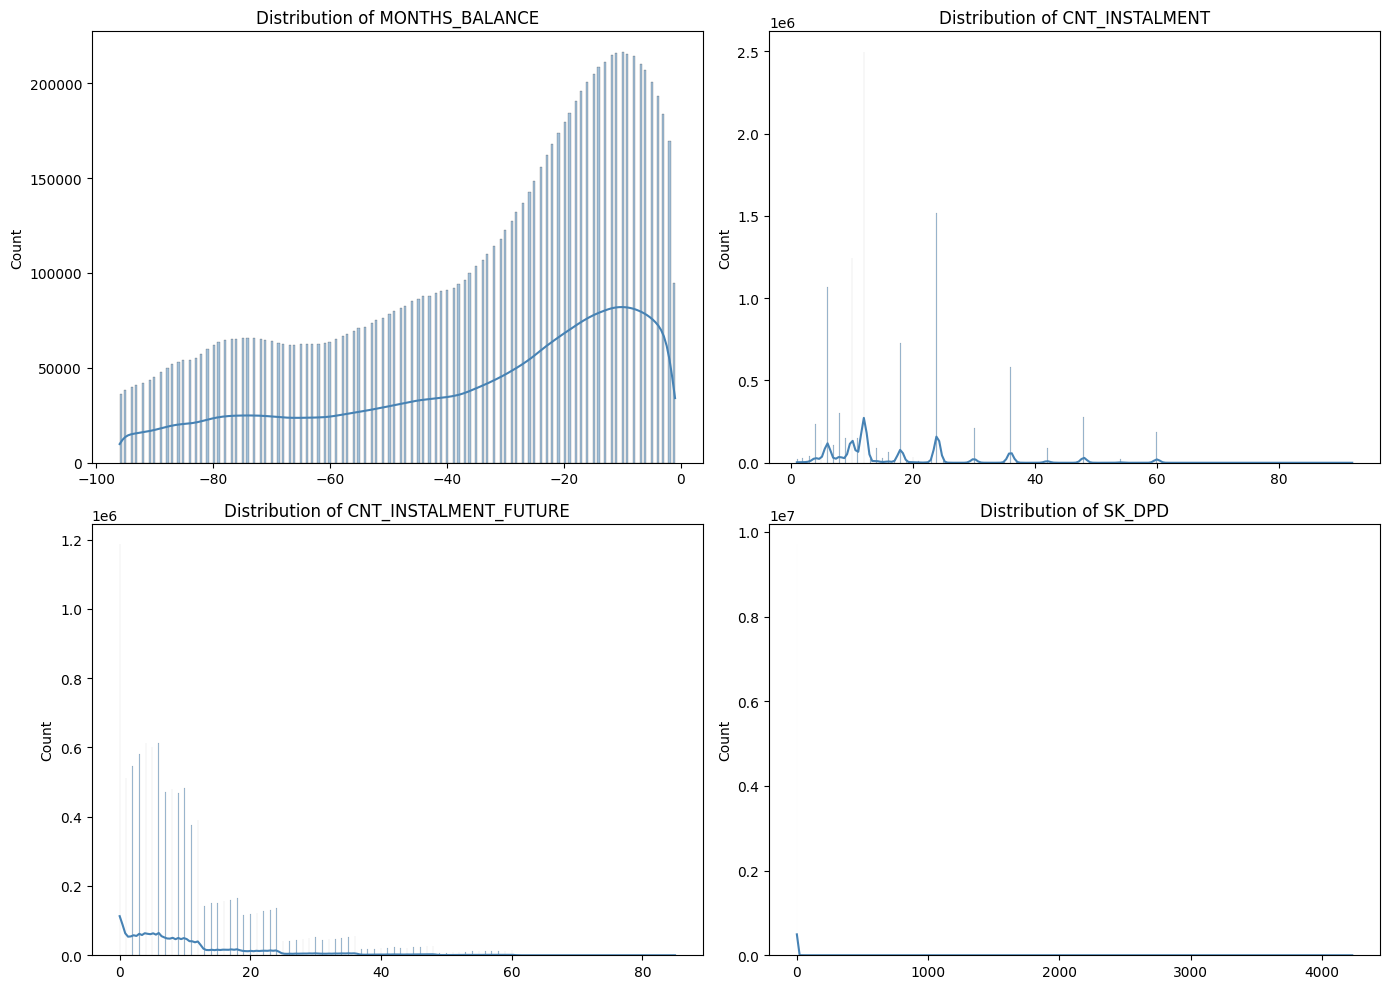

In [9]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'MONTHS_BALANCE', 'CNT_INSTALMENT',
    'CNT_INSTALMENT_FUTURE', 'SK_DPD'
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_pos[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `MONTHS_BALANCE` shows a right-skewed distribution concentrated near 0 (most recent months) with a gradual taper toward -96, consistent with accumulation of more recent monthly records across all active loans.
- `CNT_INSTALMENT` shows a discrete distribution with distinct spikes at standard loan terms (6, 12, 18, 24, 36 months), reflecting structured loan products. No anomalies detected.
- `CNT_INSTALMENT_FUTURE` is heavily concentrated near 0 with a rapid decline, indicating most observations are near the end of the repayment schedule. Consistent with the dataset being dominated by Active status records.
- `SK_DPD` is almost entirely at zero with an extremely long right tail extending to ~4,000, confirming overdue events are rare but severe when they occur. **Capping recommended.**

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

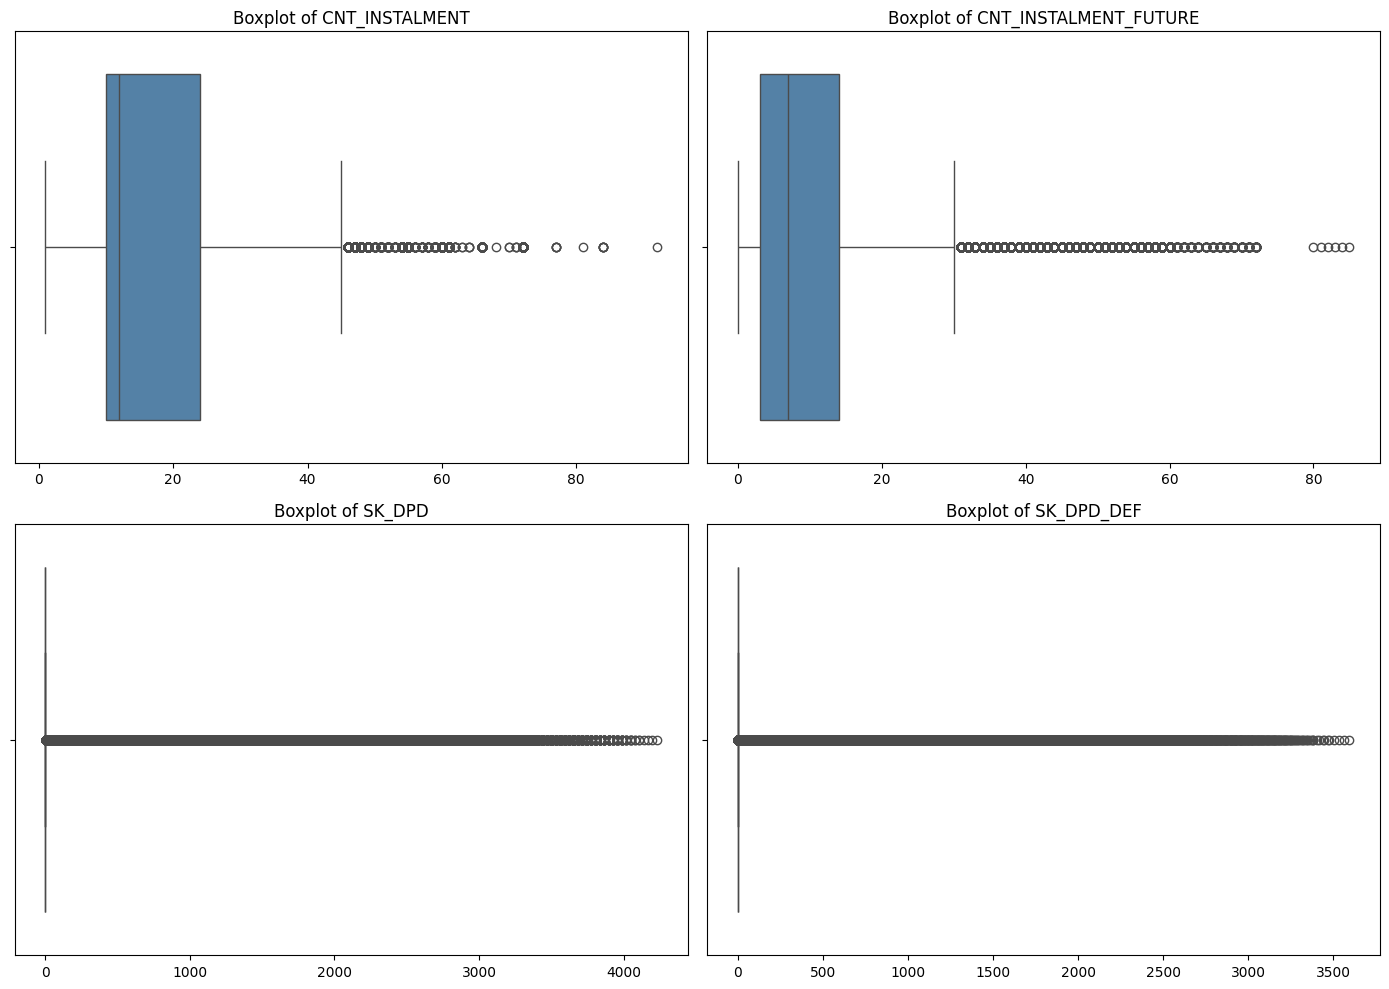

In [10]:
# Select key numerical features for outlier detection
outlier_features = [
    'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE',
    'SK_DPD', 'SK_DPD_DEF'
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_pos[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



##### Key Findings

- `CNT_INSTALMENT` shows moderate outliers above 45 months, reflecting longer-term loan products. Reasonable range, no special handling required.
- `CNT_INSTALMENT_FUTURE` shows sparse outliers above 40, consistent with loans early in their repayment schedule. No special handling required.
- `SK_DPD` shows extreme outliers extending to 4,231 with the entire IQR compressed at zero, **needs capping.**
- `SK_DPD_DEF` shows similar pattern with outliers extending to 3,595, **needs capping.**

All DPD features require outlier treatment before aggregation and modeling. Capping at 99th percentile is recommended.

---

## 4.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `POS_CASH_balance` to detect multicollinearity and identify redundant features before aggregation.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

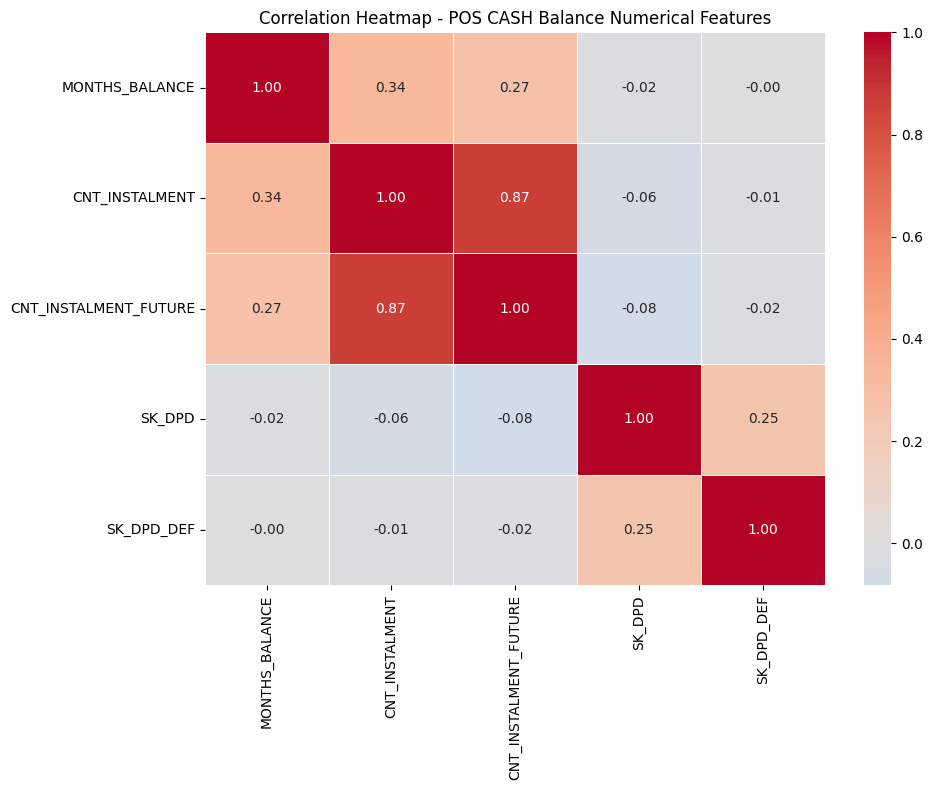

In [11]:
# Correlation heatmap - POS_CASH_balance numerical features
plt.figure(figsize=(10, 8))
corr_pos = df_pos[num_cols_pos].corr()
sns.heatmap(
    corr_pos,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - POS CASH Balance Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**High Correlation: CNT_INSTALMENT and CNT_INSTALMENT_FUTURE**
`CNT_INSTALMENT` and `CNT_INSTALMENT_FUTURE` are highly correlated (0.87), which is expected as loans with more total installments naturally tend to have more remaining installments. During aggregation, consider deriving a ratio feature `CNT_INSTALMENT_FUTURE / CNT_INSTALMENT` to capture loan completion progress instead of retaining both raw features.

**Moderate Correlation: MONTHS_BALANCE with Installment Features**
`MONTHS_BALANCE` shows moderate correlation with `CNT_INSTALMENT` (0.34) and `CNT_INSTALMENT_FUTURE` (0.27), suggesting longer-term loans tend to have more historical monthly records. Both can be retained as they capture different dimensions.

**Low Correlation: DPD Features vs Others**
`SK_DPD` and `SK_DPD_DEF` show near-zero correlation with installment and balance features, confirming that delinquency behavior is independent of loan size and term structure. Both DPD features are moderately correlated with each other (0.25), expected as they measure related overdue concepts.

**Features to Watch During Aggregation**
- `CNT_INSTALMENT` and `CNT_INSTALMENT_FUTURE`: consider deriving `INSTALMENT_COMPLETION_RATIO` instead of retaining both
- `SK_DPD` and `SK_DPD_DEF`: retain both as they capture slightly different dimensions of overdue behavior

---

# 5. Categorical Features Analysis

## 5.1 Univariate Analysis

Univariate analysis for categorical features examines each feature independently
to understand its category distribution, frequency, and concentration.

The approach includes:
- **Describing** each feature through unique value counts, most frequent category, and its frequency percentage
- **Identifying** dominant categories, near-constant features, and rare categories that may need handling

### 5.1.1 Statistical Descriptive

In [12]:
# Select categorical features
cat_features_pos = df_pos.select_dtypes(include='object').columns

# Build summary: unique values, most frequent category, and its frequency
cat_summary_pos = pd.DataFrame({
    'Unique_Values': df_pos[cat_features_pos].nunique(),
    'Most_Frequent': df_pos[cat_features_pos].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df_pos[cat_features_pos].apply(lambda x: x.value_counts().iloc[0]),
    'Frequency_%': df_pos[cat_features_pos].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary_pos

,Unique_Values,Most_Frequent,Frequency,Frequency_%
NAME_CONTRACT_STATUS,9,Active,9151119,91.5


In [13]:
# Looking for values from each feature
for col in df_pos.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df_pos[col].value_counts())


NAME_CONTRACT_STATUS:
NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64


##### Key Findings

**NAME_CONTRACT_STATUS**
`Active` dominates at 91.50%, confirming that the vast majority of monthly records represent ongoing loan months. `Completed` accounts for 7.45%, representing fully settled loan months. Remaining categories (`Demand`, `Returned to the store`, `Approved`, `Amortized debt`, `Canceled`, `XNA`) collectively account for less than 1% of records but may carry meaningful risk signal during aggregation.

**Near-Constant Distribution**
With 91.50% dominated by a single category, `NAME_CONTRACT_STATUS` has limited variation in raw form. Its value lies primarily in aggregated features such as count of `Demand` months or proportion of `Completed` months per applicant rather than as a direct feature.

**Rare Categories**
`Canceled` (15 records) and `XNA` (2 records) are negligible and should be grouped into an `Other` category or dropped during feature engineering.

---

### 5.1.2 Frequency Plot

Bar plots are used to visualize the frequency distribution of each categorical feature.
This helps identify dominant categories, class imbalance within features,
and rare categories that may need grouping before modeling.

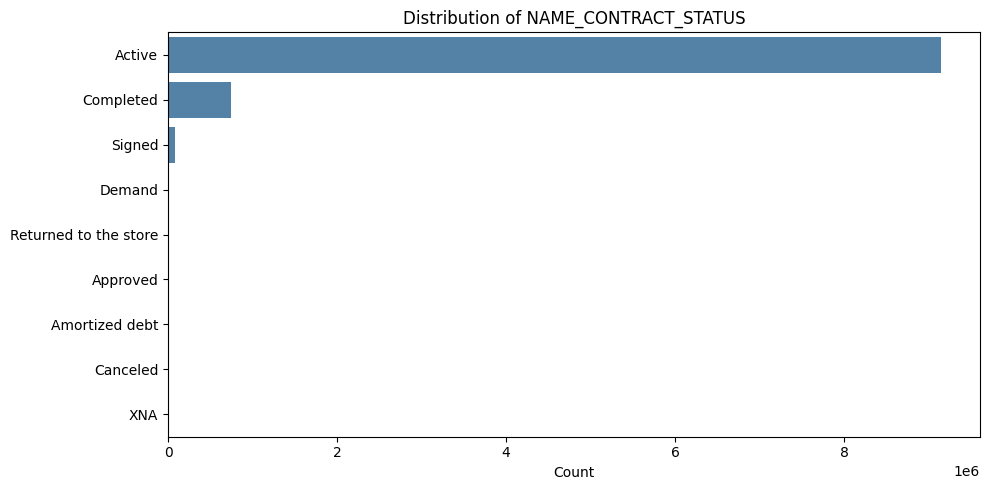

In [14]:
# Frequency plot - NAME_CONTRACT_STATUS
plt.figure(figsize=(10, 5))
order = df_pos['NAME_CONTRACT_STATUS'].value_counts().index
sns.countplot(
    data=df_pos, y='NAME_CONTRACT_STATUS',
    order=order, color='steelblue'
)
plt.title('Distribution of NAME_CONTRACT_STATUS')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5.2 Bivariate Between Features

This section examines the relationship between `NAME_CONTRACT_STATUS` and the target variable (`TARGET`) to identify which contract status categories carry the highest default risk.

The approach includes:
- **Evaluating** default rate differences across contract status categories after joining with TARGET

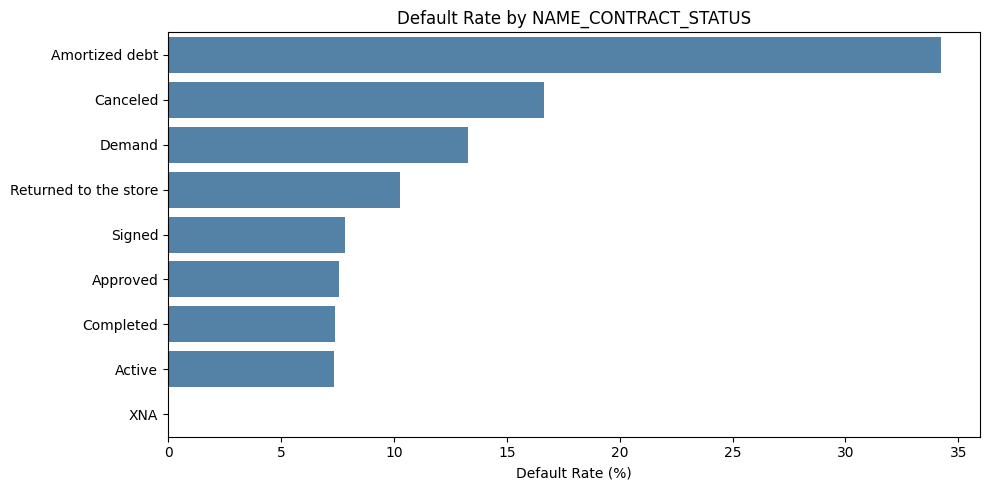

In [15]:
# Join POS_CASH_balance with TARGET from app_train
df_pos_target = df_pos.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

# Default rate by NAME_CONTRACT_STATUS
default_rate_pos = df_pos_target.groupby('NAME_CONTRACT_STATUS')['TARGET'].mean() * 100
default_rate_pos = default_rate_pos.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=default_rate_pos.values, y=default_rate_pos.index, color='steelblue')
plt.title('Default Rate by NAME_CONTRACT_STATUS')
plt.xlabel('Default Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

##### Key Findings

**Amortized Debt is the Highest Risk Status**
`Amortized debt` shows the highest default rate (~34%), indicating applicants with previously amortized loans carry significantly elevated current default risk. Despite having only 636 records, this status is a strong risk signal worth preserving as a binary indicator during aggregation.

**Canceled and Demand Carry Elevated Risk**
`Canceled` (~17%) and `Demand` (~13%) show notably higher default rates than the baseline. `Demand` status indicates loans where full repayment was demanded early, confirming financial distress. `Returned to the store` (~10%) also shows elevated risk, likely reflecting consumer loan cancellations.

**Active and Completed Show Similar Baseline Risk**
`Active` (~7%) and `Completed` (~7%) show the lowest default rates among meaningful categories, consistent with normal loan behavior. The near-identical rates suggest that simply having an active or completed loan does not strongly differentiate risk on its own.

**XNA Shows Near-Zero Default Rate**
`XNA` (2 records only) shows near-zero default rate and should be dropped or grouped into `Other` before modeling.

**Implication for Aggregation**
Key aggregated features to derive from `NAME_CONTRACT_STATUS` include count of `Demand` months, count of `Amortized debt` months, and binary flags for ever having these high-risk statuses, as they carry the strongest default signal.

---

# Agregation

This section aggregates `POS_CASH_balance` into applicant-level features ready for merging into the main modeling table. Aggregation is performed in a single step directly to `SK_ID_CURR` level.

The approach includes:
- **Aggregating** `POS_CASH_balance` to `SK_ID_CURR` level to derive applicant-level POS and cash loan behavior features

## POS CASH Balance to SK_ID_CURR

Monthly balance records are aggregated to applicant level using `SK_ID_CURR` as the key. This produces one row per applicant containing summarized POS and cash loan behavior features ready for merging into `application_train`.

In [16]:
# Aggregate POS_CASH_balance to SK_ID_CURR level
df_pos_agg = df_pos.groupby('SK_ID_CURR').agg(
    # Record count
    POS_COUNT=('SK_ID_PREV', 'count'),
    POS_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),

    # Months balance
    POS_MONTHS_BALANCE_MEAN=('MONTHS_BALANCE', 'mean'),
    POS_MONTHS_BALANCE_MIN=('MONTHS_BALANCE', 'min'),

    # Instalment features
    POS_CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
    POS_CNT_INSTALMENT_MAX=('CNT_INSTALMENT', 'max'),
    POS_CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
    POS_CNT_INSTALMENT_FUTURE_MAX=('CNT_INSTALMENT_FUTURE', 'max'),

    # DPD features
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_MAX=('SK_DPD', 'max'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    POS_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),

    # Contract status counts
    POS_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    POS_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    POS_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
    POS_AMORTIZED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Amortized debt').sum()),
    POS_RETURNED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Returned to the store').sum()),
).reset_index()

In [17]:
# Proportion features
df_pos_agg['POS_PROP_ACTIVE'] = (df_pos_agg['POS_ACTIVE_COUNT'] / df_pos_agg['POS_COUNT']).round(4)
df_pos_agg['POS_PROP_COMPLETED'] = (df_pos_agg['POS_COMPLETED_COUNT'] / df_pos_agg['POS_COUNT']).round(4)

# Binary flag features
df_pos_agg['POS_HAS_DEMAND'] = (df_pos_agg['POS_DEMAND_COUNT'] >= 1).astype(int)
df_pos_agg['POS_HAS_AMORTIZED'] = (df_pos_agg['POS_AMORTIZED_COUNT'] >= 1).astype(int)

# Instalment completion ratio
df_pos_agg['POS_INSTALMENT_COMPLETION_RATIO'] = (
    1 - (df_pos_agg['POS_CNT_INSTALMENT_FUTURE_MEAN'] / df_pos_agg['POS_CNT_INSTALMENT_MEAN'])
).round(4)

print("Shape df_pos_agg:", df_pos_agg.shape)
df_pos_agg.head()

Shape df_pos_agg: (337252, 23)


,SK_ID_CURR,POS_COUNT,POS_UNIQUE_LOANS,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_MIN,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,...,POS_ACTIVE_COUNT,POS_COMPLETED_COUNT,POS_DEMAND_COUNT,POS_AMORTIZED_COUNT,POS_RETURNED_COUNT,POS_PROP_ACTIVE,POS_PROP_COMPLETED,POS_HAS_DEMAND,POS_HAS_AMORTIZED,POS_INSTALMENT_COMPLETION_RATIO
0,100001,9,2,-72.555556,-96,4.000000,4.0,1.444444,4.0,0.777778,...,7,2,0,0,0,0.7778,0.2222,0,0,0.6389
1,100002,19,1,-10.000000,-19,24.000000,24.0,15.000000,24.0,0.000000,...,19,0,0,0,0,1.0000,0.0000,0,0,0.3750
2,100003,28,3,-43.785714,-77,10.107143,12.0,5.785714,12.0,0.000000,...,26,2,0,0,0,0.9286,0.0714,0,0,0.4276
3,100004,4,1,-25.500000,-27,3.750000,4.0,2.250000,4.0,0.000000,...,3,1,0,0,0,0.7500,0.2500,0,0,0.4000
4,100005,11,1,-20.000000,-25,11.700000,12.0,7.200000,12.0,0.000000,...,9,1,0,0,0,0.8182,0.0909,0,0,0.3846


In [18]:
# Merge POS_CASH_balance aggregations with application_train
df_pos_agg_target = df_pos_agg.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

print("Shape df_pos_agg_target:", df_pos_agg_target.shape)

Shape df_pos_agg_target: (337252, 24)


# 6. Bivariate Aggregated Features vs TARGET

This section examines the relationship between aggregated POS_CASH_balance features and the target variable (`TARGET`). The goal is to identify which aggregated features carry the strongest signal for predicting loan default.

The approach includes:
- **KDE plots** to compare distributions of aggregated numerical features between default and non-default applicants
- **Default rate plots** to evaluate default rate per category for aggregated categorical features

## 6.1 Numerical Aggregated Features

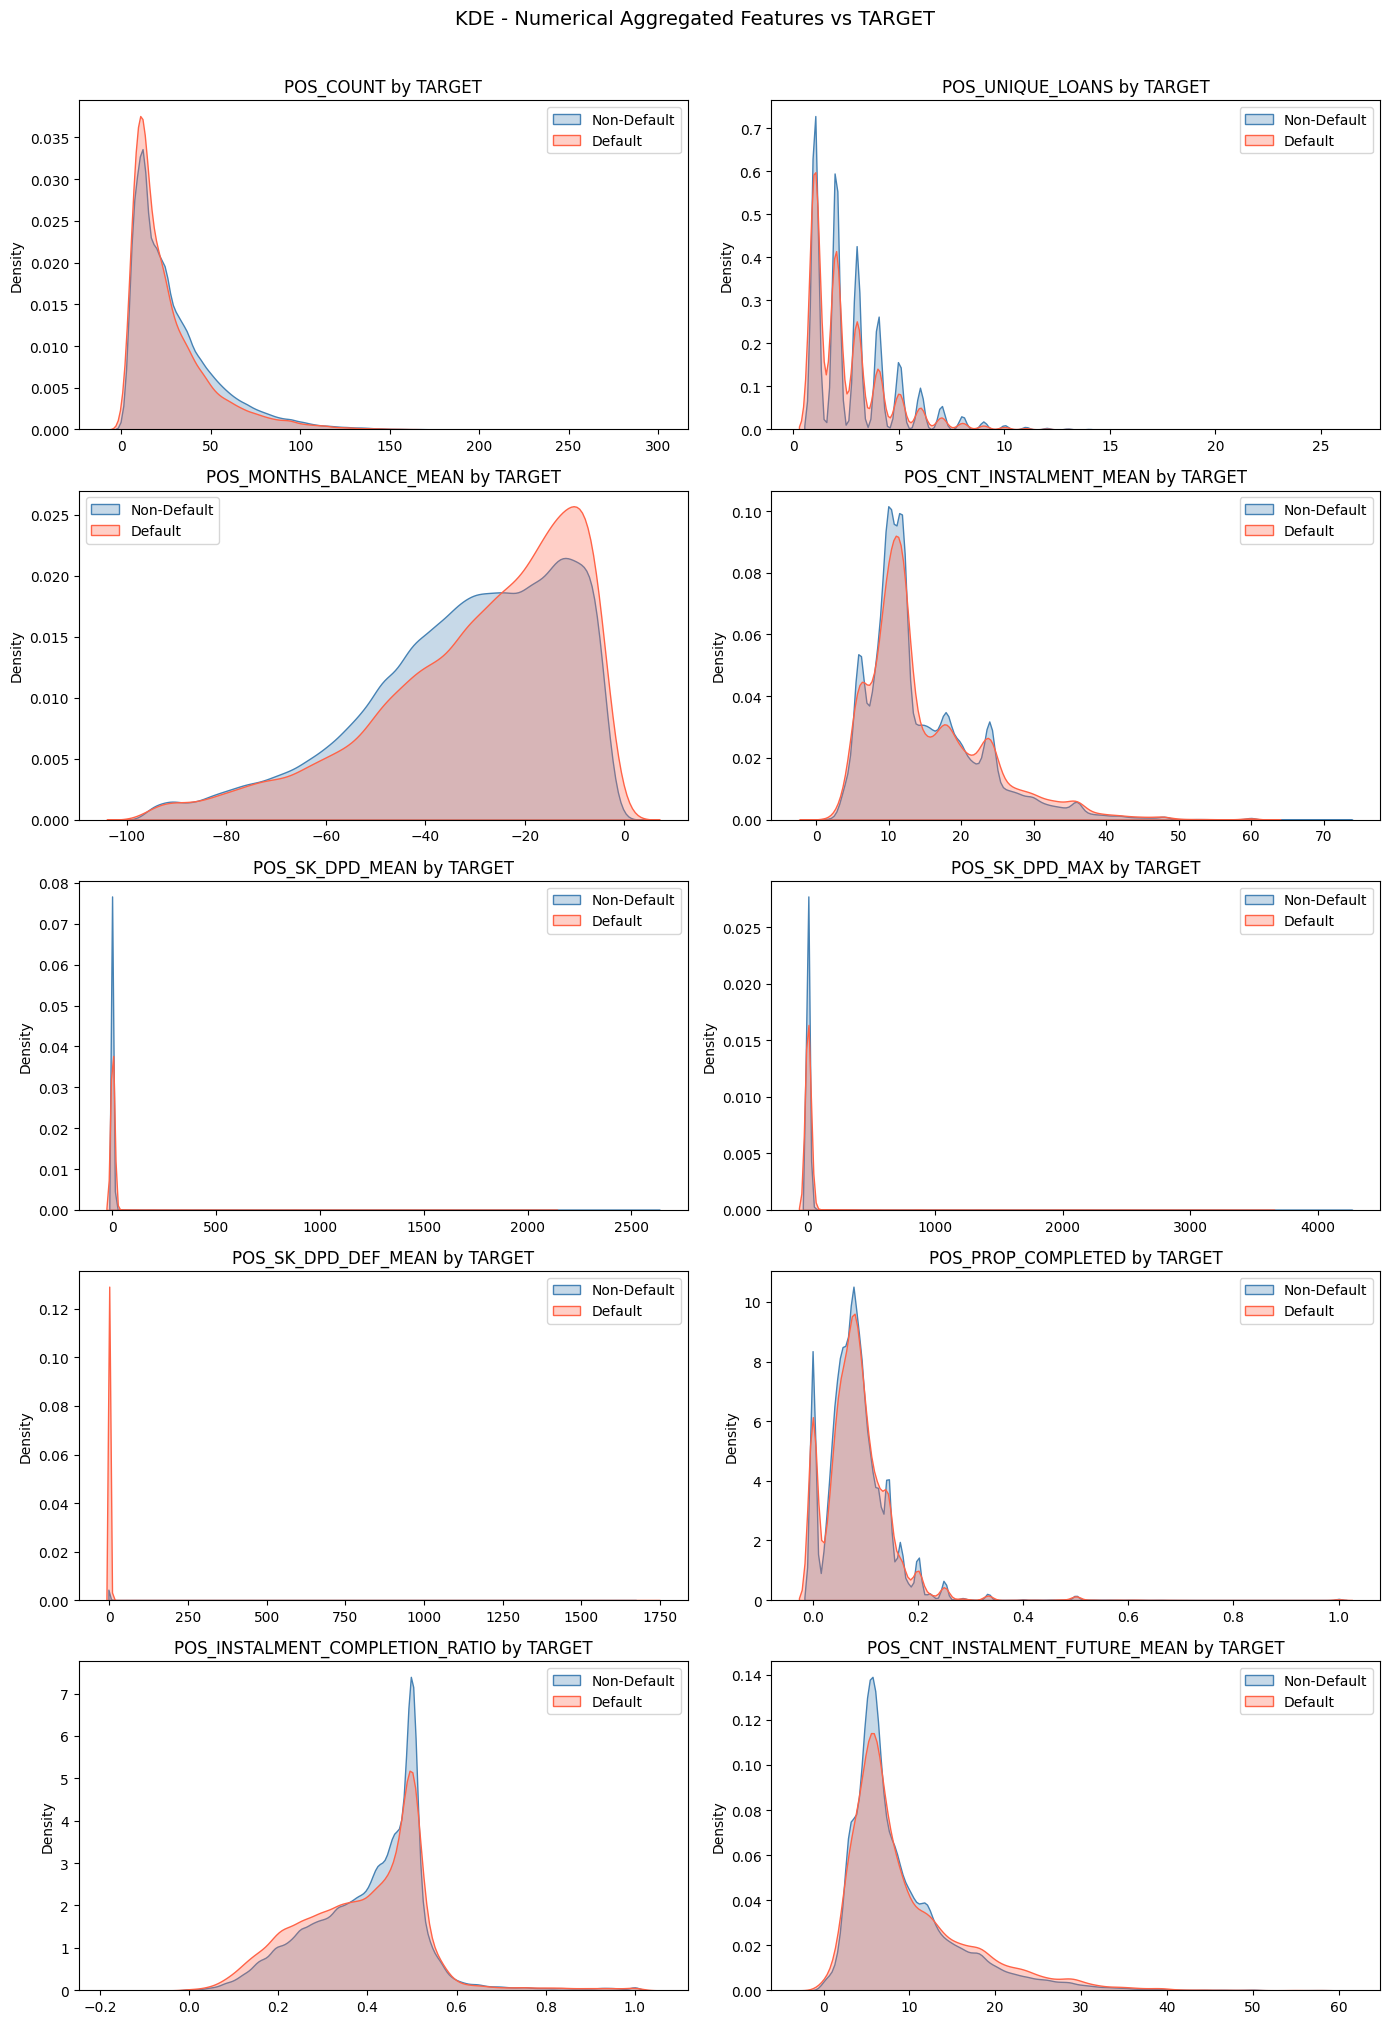

In [19]:
# Select key numerical aggregated features for bivariate analysis
num_agg_features = [
    'POS_COUNT',
    'POS_UNIQUE_LOANS',
    'POS_MONTHS_BALANCE_MEAN',
    'POS_CNT_INSTALMENT_MEAN',
    'POS_SK_DPD_MEAN',
    'POS_SK_DPD_MAX',
    'POS_SK_DPD_DEF_MEAN',
    'POS_PROP_COMPLETED',
    'POS_INSTALMENT_COMPLETION_RATIO',
    'POS_CNT_INSTALMENT_FUTURE_MEAN',
]

# Grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_agg_features):
    for target_val, label, color in zip([0, 1], ['Non-Default', 'Default'], ['steelblue', 'tomato']):
        subset = df_pos_agg_target[df_pos_agg_target['TARGET'] == target_val][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by TARGET')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('KDE - Numerical Aggregated Features vs TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Key Findings - Numerical Aggregated Features

**POS_COUNT**
Default applicants tend to have fewer total POS/cash loan monthly records, with both distributions concentrated near 0-50. Non-default applicants show a slightly heavier tail toward higher counts, suggesting more extensive loan history is associated with lower risk.

**POS_UNIQUE_LOANS**
Default applicants show higher density at 1-2 unique loans while non-default applicants spread more toward higher unique loan counts. Having only 1 previous POS/cash loan is associated with slightly higher default risk.

**POS_MONTHS_BALANCE_MEAN**
Clear separation between classes. Default applicants are concentrated near more recent months (less negative), while non-default applicants spread further into older history. Longer observable loan history is associated with lower default risk.

**POS_CNT_INSTALMENT_MEAN**
Both classes show similar discrete distribution patterns at standard loan terms, but default applicants show slightly higher density at shorter terms (6-12 months). Longer average loan terms are mildly associated with lower default risk.

**POS_SK_DPD_MEAN and POS_SK_DPD_MAX**
Both distributions are heavily compressed near zero with long right tails, making visual separation difficult. However, any non-zero DPD value carries meaningful risk signal. Requires outlier treatment before use in modeling.

**POS_SK_DPD_DEF_MEAN**
Similar pattern to DPD features, compressed near zero with extreme outliers. Default applicants show slightly heavier tail toward higher values.

**POS_PROP_COMPLETED**
Both classes show similar distributions concentrated near 0, with default applicants showing slightly lower completion proportions. Limited discriminative power in isolation.

**POS_INSTALMENT_COMPLETION_RATIO**
Both classes peak near 0.5 with non-default applicants showing a stronger peak near 1.0, suggesting applicants who complete more of their installment schedule are associated with lower default risk.

**POS_CNT_INSTALMENT_FUTURE_MEAN**
Distributions largely overlap with both classes concentrated near 0-10 remaining installments. Limited discriminative power on its own.

---

## 6.2 Categorical Aggregated Features

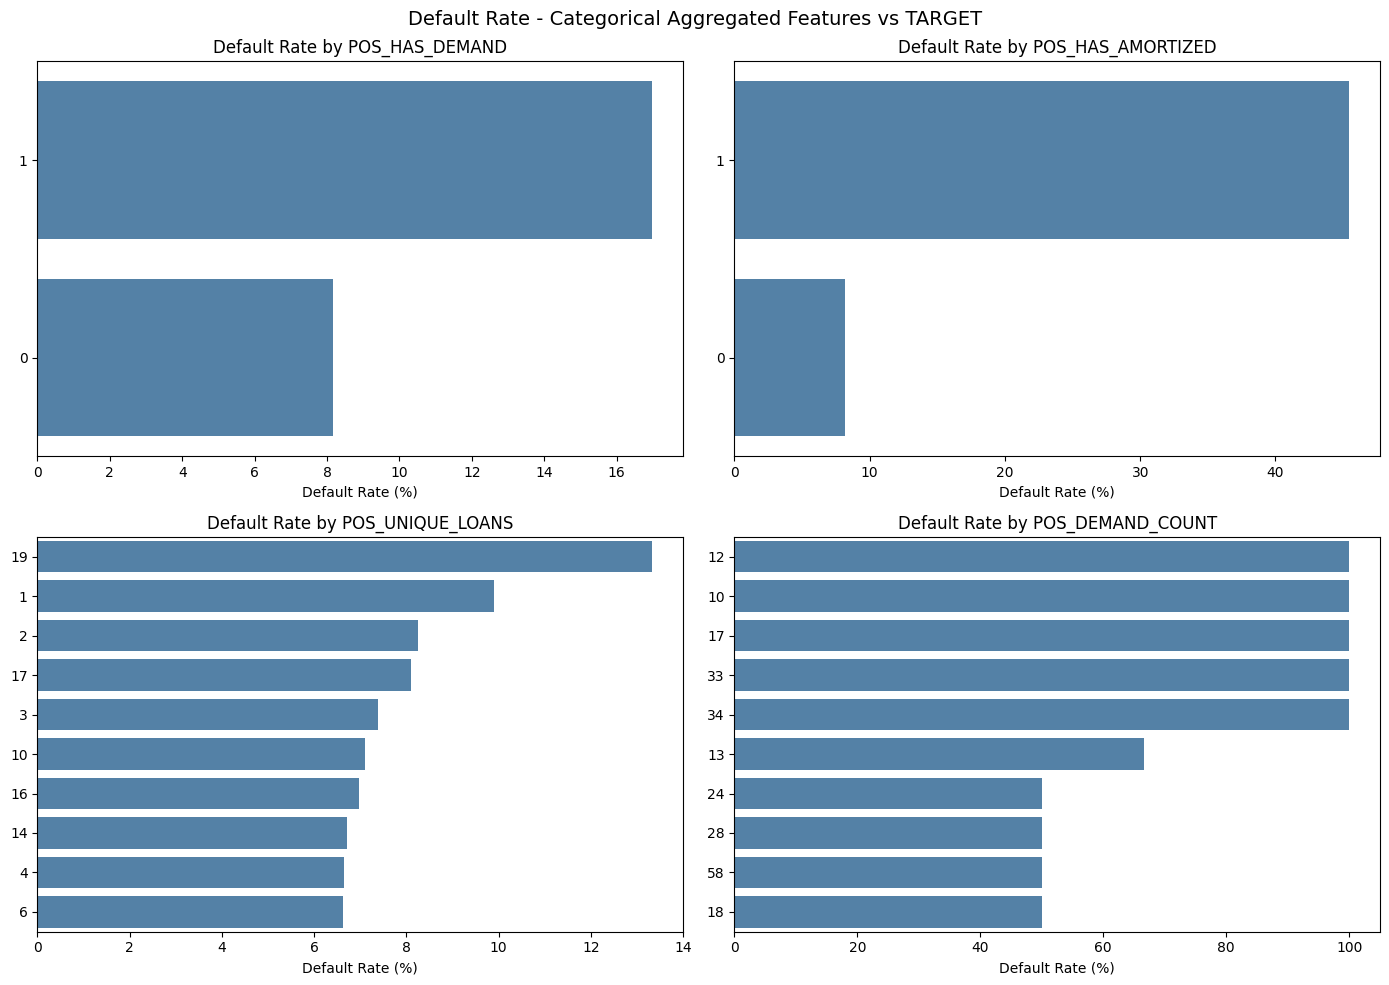

In [20]:
# Select categorical aggregated features for default rate analysis
cat_agg_features = [
    'POS_HAS_DEMAND',
    'POS_HAS_AMORTIZED',
    'POS_UNIQUE_LOANS',
    'POS_DEMAND_COUNT',
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_agg_features):
    default_rate = df_pos_agg_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False).head(10)
    sns.barplot(x=default_rate.values, y=default_rate.index.astype(str),
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.suptitle('Default Rate - Categorical Aggregated Features vs TARGET', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings - Categorical Aggregated Features

**POS_HAS_DEMAND**
Applicants with at least one `Demand` status month show default rate of ~17% compared to ~8% for those without. Having ever experienced a demand status is a meaningful binary risk signal.

**POS_HAS_AMORTIZED**
Applicants with at least one `Amortized debt` status month show default rate of ~50% compared to ~9% for those without. This is one of the strongest binary risk signals in this dataset, confirming findings from Section 5.2.

**POS_UNIQUE_LOANS**
Non-linear relationship where applicants with only 1 unique loan show higher default rate (~10%) while those with moderate counts (4-6) show lower rates (~6-7%). Very high unique loan counts (19) show elevated rates again, suggesting extreme borrowing history carries risk.

**POS_DEMAND_COUNT**
Strong monotonic relationship where higher demand month counts are associated with dramatically higher default rates, reaching 100% at counts of 10 or more. Even a single demand month significantly elevates risk.

---

# 7. Insights & Recommendations

## 7.1 Key Findings

**POS/Cash Loan Coverage**
337,252 unique applicants have POS_CASH_balance records, covering approximately 109% of `application_train` applicants. After merging, applicants with no POS/cash loan history should be handled with appropriate imputation.

**Amortized Debt is the Strongest Risk Signal**
`POS_HAS_AMORTIZED` shows a default rate of ~50% for applicants with at least one amortized debt month, making it one of the strongest binary risk signals across all datasets analyzed so far. Despite being rare, this status should always be preserved as a binary indicator.

**Demand Status Confirms Financial Distress**
`POS_HAS_DEMAND` and `POS_DEMAND_COUNT` show clear monotonic relationships with default rate. Applicants with demand status months show default rates reaching 100% at high counts, confirming that early loan termination demand is a strong predictor of current default risk.

**DPD Features Require Treatment**
`POS_SK_DPD_MAX` and `POS_SK_DPD_DEF_MAX` show extreme outliers up to 4,231 and 3,595 respectively. In raw form these features have limited visual discriminative power due to compression near zero, but non-zero values carry meaningful signal. Capping at 99th percentile is recommended.

**Loan History Depth as Risk Indicator**
`POS_MONTHS_BALANCE_MEAN` shows visible class separation, with default applicants having more recent loan history. Longer observable POS/cash loan history is consistently associated with lower default risk.

**Instalment Completion as Behavioral Signal**
`POS_INSTALMENT_COMPLETION_RATIO` shows non-default applicants with a stronger peak near 1.0, indicating more complete repayment schedules. This derived feature captures loan progress behavior that neither raw installment count alone provides.

---

## 7.2 Reommended Aggregated Features

**Count Features:**
- `POS_COUNT`: total monthly records per applicant
- `POS_UNIQUE_LOANS`: number of distinct POS/cash loans
- `POS_DEMAND_COUNT`: count of demand status months
- `POS_AMORTIZED_COUNT`: count of amortized debt months

**DPD Features:**
- `POS_SK_DPD_MEAN`, `POS_SK_DPD_MAX`: average and worst days past due
- `POS_SK_DPD_DEF_MEAN`, `POS_SK_DPD_DEF_MAX`: defined DPD variants

**Temporal Features:**
- `POS_MONTHS_BALANCE_MEAN`, `POS_MONTHS_BALANCE_MIN`: loan history depth

**Instalment Features:**
- `POS_CNT_INSTALMENT_MEAN`: average loan term length
- `POS_INSTALMENT_COMPLETION_RATIO`: derived loan progress ratio

**Binary Flag Features:**
- `POS_HAS_DEMAND`: binary flag for ever having demand status
- `POS_HAS_AMORTIZED`: binary flag for ever having amortized debt status

**Proportion Features:**
- `POS_PROP_COMPLETED`: proportion of completed loan months
- `POS_PROP_ACTIVE`: proportion of active loan months

---


## 7.3 Handling Strategy

**Missing Values after Merge:**
- Applicants with no POS_CASH_balance records will have all `POS_*` features as NaN after merging. Impute with **0** for count, DPD, and binary flag features, as absence of POS/cash loan history is a meaningful signal in itself.
- `POS_INSTALMENT_COMPLETION_RATIO`: impute with **0** for applicants with no records, and investigate NaN values arising from zero `CNT_INSTALMENT_MEAN` before aggregation.

**Outlier Treatment:**
- `POS_SK_DPD_MAX`, `POS_SK_DPD_MEAN`: cap at 99th percentile before use in modeling
- `POS_SK_DPD_DEF_MAX`, `POS_SK_DPD_DEF_MEAN`: cap at 99th percentile

**Low-Signal Features:**
- `POS_PROP_COMPLETED` and `POS_CNT_INSTALMENT_FUTURE_MEAN`: limited discriminative power on their own, consider dropping if feature importance is low after modeling

**All transformations and imputations to be implemented in `Data Cleaning and Handling.ipynb`.**

---

In [1]:
# Read markdown cells from notebook
import json

with open('EDA_POS_CASH_balance.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: POS_CASH_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `POS_CASH_balance` dataset from the Home Credit risk modeling case. This table contains monthly balance snapshots of previous POS and cash loans held by applicants at Home Credit, providing behavioral signals on installment payment history for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `POS_CASH_balance` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

##